<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/09_prezentacija.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="text-align:center">
<h1 style="text-align:center">🐱🐭 Tom &amp; Jerry Character Classification</h1>
<h3 style="text-align:center">Klasifikacija likova iz crtanog filma <em>Tom and Jerry</em></h3>
<p style="text-align:center"><strong>Mašinsko učenje — prezentacija za odbranu projekta</strong></p>
<p style="text-align:center">Ika Bibić &amp; Blagoje Rozgić</p>
<p style="text-align:center"><a href="https://github.com/ilinkabibic/Tom-and-Jerry-Character-Classification">github.com/ilinkabibic/Tom-and-Jerry-Character-Classification</a></p>
</div>


## 1. Problem

- Klasifikacija video-frejmova iz crtanog filma **Tom and Jerry** u jednu od **4 klase**:
  - `tom`, `jerry`, `both` (oba lika na slici), `neither` (nijedan lik)
- Cilj projekta: uporediti **klasičan ML** pristup (ručno izvučene osobine + klasifikator) i **duboko učenje**
  (konvoluciona mreža od nule i transfer learning) na istom zadatku i istim podacima
- Poseban fokus: **metodološka korektnost** podjele podataka i **interpretabilnost** modela (Grad-CAM)


## 2. Skup podataka

- Izvor: [Tom and Jerry Image Classification](https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification) — Kaggle
- Frejmovi izvučeni iz epizoda crtanog filma, ručno označeni po klasi lika
- Ukupno **5478** označenih slika

| Podskup | Broj slika |
|---|---|
| Trening (train) | 3755 |
| Validacija (val) | 847 |
| Test | 844 |
| Izuzeto (`challenges.csv`, pravi held-out) | 32 |

- `challenges.csv` — 32 posebno teške slike koje je autor skupa sam izdvojio kao izazovne primjere


## 3. Metodologija — otkriveno curenje podataka (data leakage)

**Izazov na koji smo naišli tokom rada:**

- U ranoj verziji projekta, 32 slike iz `challenges.csv` bile su raspoređene i po train/val/test skupu
- To znači da bi model mogao da **"vidi" iste slike i u treningu i u posebnoj analizi izazovnih primjera** → curenje podataka
- **Rešenje:** u `01_eda_split.ipynb` dodata nova vrijednost `'excluded'` u koloni `split`, kojom se svih 32 `challenges.csv` slika izuzima iz train/val/test

```python
gt.loc[gt['filename'].isin(challenge_filenames), 'split'] = 'excluded'
```

- Nakon izmjene, **svi modeli su ponovo trenirani i evaluirani** na ispravljenom, curenju-otpornom splitu
- `challenges.csv` je time postao **pravi, do sada nekorišćen held-out skup** — koristan za notesku 07


## 4. Korišćeni modeli

| # | Model | Tip | Osobine / ulaz |
|---|---|---|---|
| 02 | **SVM** (RBF kernel) | klasičan ML | HOG + histogram boja |
| 03 | **Random Forest** | klasičan ML | HOG + histogram boja |
| 05 | **CNN od nule** (SmallCNN) | duboko učenje | sirove slike, 64×64 |
| 04 | **ResNet18** (transfer learning) | duboko učenje | sirove slike, 224×224, fine-tuning |

- Za klasične modele: `GridSearchCV` za izbor hiperparametara (SVM: `C`, `gamma`; RF: `n_estimators`, `max_depth`, `min_samples_leaf`)
- Za duboke modele: `PyTorch` / `torchvision`, ResNet18 sa ImageNet težinama kao polazna tačka


## 5. Rezultati na test skupu (844 slike)

<div style="text-align:center">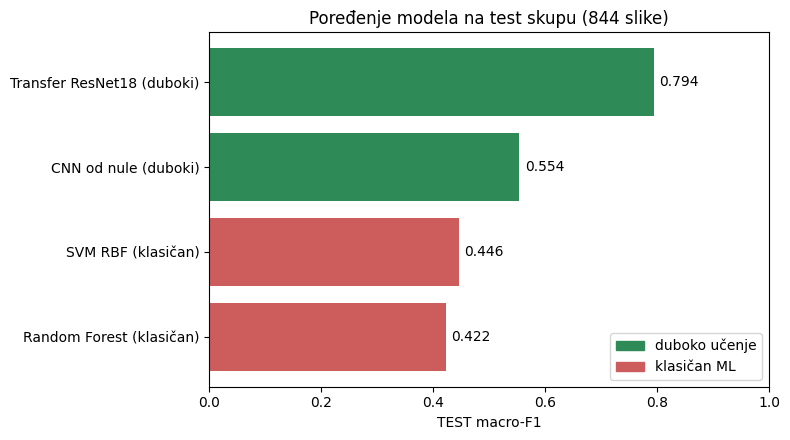</div>

**ResNet18 (transfer learning) je ubjedljivo najbolji** — macro-F1 0.794, gotovo duplo bolji od klasičnih modela.

## 6. Rezultati na pravom held-out skupu (`challenges.csv`, 32 slike)

<div style="text-align:center">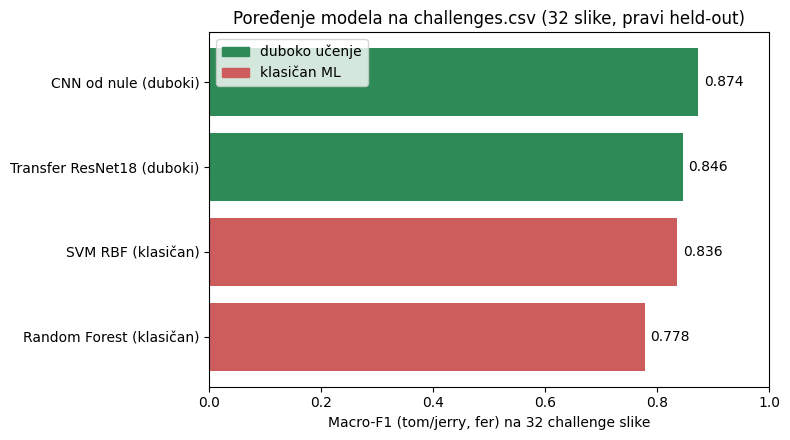</div>

Macro-F1 računat samo za klase koje se stvarno pojavljuju u ovom skupu (`tom`, `jerry`).

**Zanimljivo — poredak se mijenja u odnosu na puni test skup:** CNN od nule (0.874) neznatno nadmašuje ResNet18 (0.846) baš na najtežim slikama.

## 7. Najteže i najlakše slike iz `challenges.csv`

<div style="text-align:center">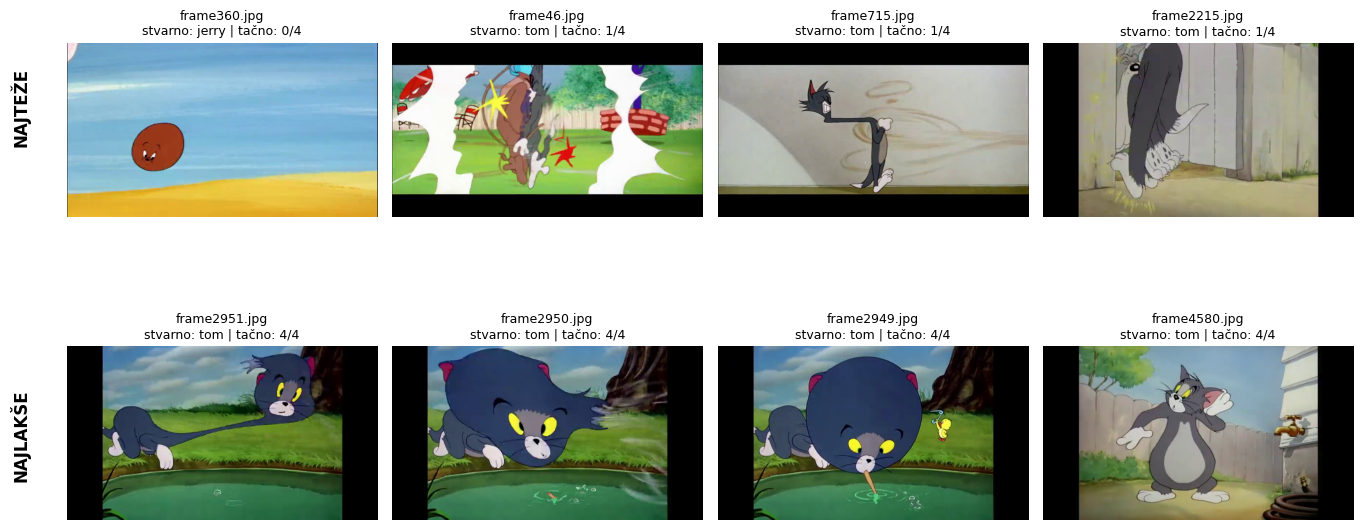</div>

`frame360.jpg` — nijedan od 4 modela nije pogodio (0/4), tačan odgovor: `jerry`.

Na slici se zapravo vidi crvena lopta/kamen na plaži — vizuelno gotovo ne liči na lik, što potvrđuje da je autor skupa opravdano označio ovu sliku kao izazovnu.

## 8. Demo — klasifikacija uživo, sva 4 modela (`08_demo.ipynb`)

<div style="text-align:center">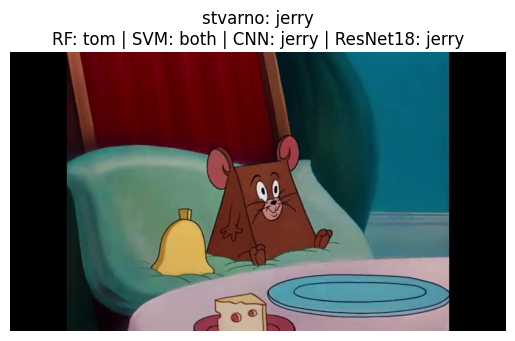</div>

Primjer: `frame1794.jpg` (stvarno: `jerry`)

- Random Forest → `tom` ❌
- SVM → `both` ❌
- CNN od nule → `jerry` ✅
- ResNet18 → `jerry` ✅

Slika namjerno izabrana jer duboki modeli tačno klasifikuju, a klasični ne — dobra ilustracija razlike u pristupima.

## 9. Grad-CAM — gdje ResNet18 "gleda" na slici

<div style="text-align:center">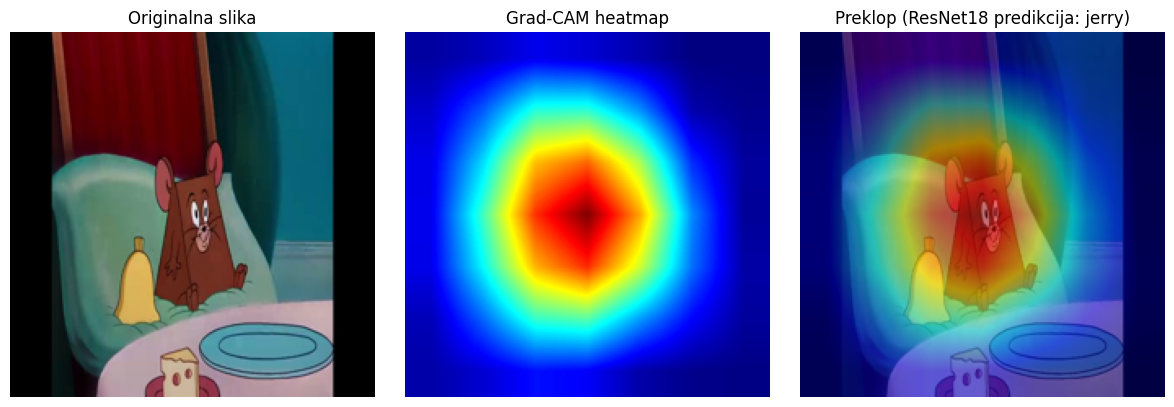</div>

ResNet18 se pri odluci jasno fokusira na sam lik (Jerry) u centru slike.

## 10. Grad-CAM — gdje CNN od nule "gleda" na slici

<div style="text-align:center">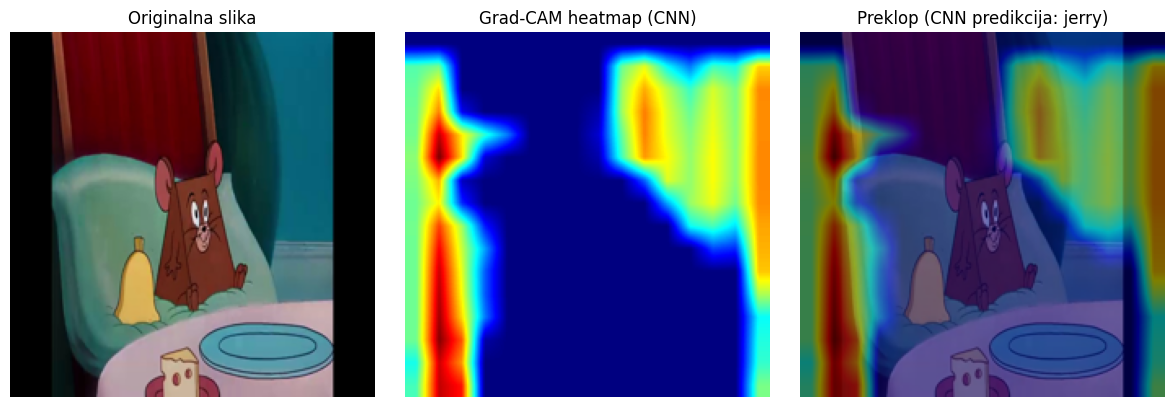</div>

CNN od nule se dijelom fokusira na **ivice i pozadinu** slike, ne samo na lika.

Moguće objašnjenje: mnogo grublja mapa osobina (8×8) i trening od nule na relativno malom skupu (~3800 slika, bez ImageNet predtreninga) — model je podložniji učenju "prečica" (shortcut learning) umjesto isključivo osobina samog lika. Ovo ne umanjuje tačnost modela, ali je bitan uvid u **kako** on donosi odluku.

## 11. Korišćene tehnologije

- **Python** — pandas, numpy
- **scikit-learn** — SVM, Random Forest, `GridSearchCV`, metrike
- **scikit-image / OpenCV** — HOG osobine, histogram boja, obrada slika
- **PyTorch / torchvision** — CNN od nule, ResNet18 transfer learning
- **Grad-CAM** — sopstvena implementacija preko forward/backward hook-ova
- **Google Colab** — trening i izvršavanje svesaka
- **Git / GitHub** — verzionisanje, timski rad, čuvanje modela


## 12. Literatura

1. *Tom and Jerry Image Classification* — Kaggle skup podataka
   https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification
2. N. Dalal, B. Triggs, **Histograms of Oriented Gradients for Human Detection**, 2005. *(HOG osobine — 02, 03)*
3. K. He et al., **Deep Residual Learning for Image Recognition**, 2016. *(ResNet arhitektura — 04)*
4. R. R. Selvaraju et al., **Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization**, 2017. *(08)*
5. Dokumentacija: [scikit-learn](https://scikit-learn.org/), [PyTorch](https://pytorch.org/)


## 13. Zaključak

- Poredak modela **nije isti na svakom podskupu**: ResNet18 je ubjedljivo najbolji na punom test skupu (macro-F1 0.79 naspram 0.55 za CNN),
  ali CNN ga neznatno nadmašuje baš na najtežim, ranije izuzetim slikama iz `challenges.csv` (0.87 naspram 0.85)
- Grad-CAM analiza djelimično objašnjava zašto: ResNet18 se fokusira na lik, dok se CNN treniran od nule oslanja i na pozadinu/ivice
- Ispravljanje curenja podataka (`challenges.csv` → pravi held-out skup) bilo je ključno da rezultati budu pouzdani i da poređenje modela ima smisla


<div style="text-align:center">
<h2 style="text-align:center">Hvala na pažnji! 🙌</h2>
<h3 style="text-align:center">Pitanja?</h3>
</div>
